In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")   # comment this out if running interactively and you want inline plots
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NUMERIC_COLS = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary",
]
CATEGORICAL_COLS = [
    "Geography", "Gender", "HasCrCard", "IsActiveMember",
]

print("=" * 70)
print("BANK CHURN CUSTOMER CLUSTERING: K-Means / Hierarchical / DBSCAN")
print("=" * 70)

BANK CHURN CUSTOMER CLUSTERING: K-Means / Hierarchical / DBSCAN


In [3]:
# ---------------------------------------------------------------------------
# 1. Load + preprocess
# ---------------------------------------------------------------------------
# >>> EDIT the filename below so it exactly matches your CSV file <<<
df = pd.read_csv("Churn_Modelling.csv")

imputer = SimpleImputer(strategy="median")
num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]), columns=NUMERIC_COLS, index=df.index
)
cat_df = pd.get_dummies(df[CATEGORICAL_COLS].astype(str), drop_first=True)

feature_df = pd.concat([num_df, cat_df], axis=1)
X = StandardScaler().fit_transform(feature_df)

print(f"Loaded {len(df):,} customers, {feature_df.shape[1]} clustering features "
      f"(Exited excluded)")

Loaded 10,000 customers, 11 clustering features (Exited excluded)


## Week 9

Saved plot -> kmeans_elbow_silhouette.png
Silhouette-suggested k = 3  (scores: k=2:0.131, k=3:0.133, k=4:0.118, k=5:0.101, k=6:0.113, k=7:0.108, k=8:0.112)


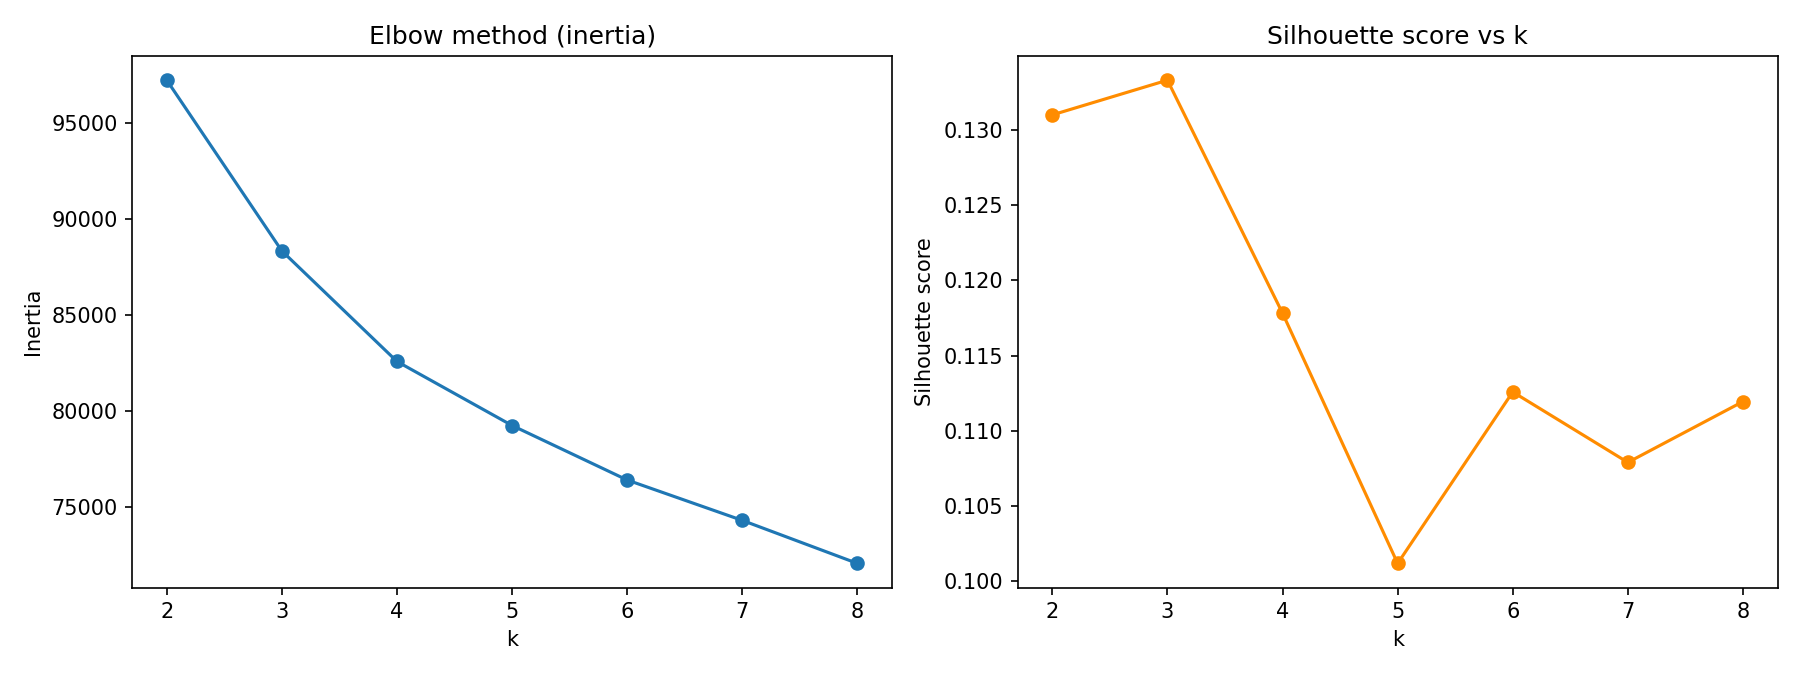

In [4]:
# ---------------------------------------------------------------------------
# 2. Choose k for K-Means via elbow + silhouette
# ---------------------------------------------------------------------------
k_range = range(2, 9)
sil_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), 5000, replace=False)
X_sil_sample = X[sil_sample_idx]

inertias, sil_scores = [], []
for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km_k.fit_predict(X)
    inertias.append(km_k.inertia_)
    sil_scores.append(silhouette_score(X_sil_sample, km_k.predict(X_sil_sample)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(list(k_range), inertias, marker="o")
ax1.set_title("Elbow method (inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

ax2.plot(list(k_range), sil_scores, marker="o", color="darkorange")
ax2.set_title("Silhouette score vs k")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=150)
print("Saved plot -> kmeans_elbow_silhouette.png")
plt.close(fig)

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Silhouette-suggested k = {best_k}  (scores: "
      + ", ".join(f"k={k}:{s:.3f}" for k, s in zip(k_range, sil_scores)) + ")")

In [5]:
# ---------------------------------------------------------------------------
# 3. K-Means on the FULL dataset
# ---------------------------------------------------------------------------
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X)

sil = silhouette_score(X[sil_sample_idx], km_labels[sil_sample_idx])
print(f"\nK-Means (k={best_k}) silhouette (5k sample): {sil:.3f}")
print("Cluster sizes:", pd.Series(km_labels).value_counts().sort_index().to_dict())

# --- Profile clusters against Exited (label used only for reporting) ---
profiled = feature_df.copy()
profiled["KMeansCluster"] = km_labels
profiled["Exited"] = df["Exited"].values

summary = profiled.groupby("KMeansCluster").agg(
    n_customers=("Exited", "size"),
    churn_rate=("Exited", "mean"),
    avg_CreditScore=("CreditScore", "mean"),
    avg_Age=("Age", "mean"),
    avg_Tenure=("Tenure", "mean"),
    avg_Balance=("Balance", "mean"),
    avg_NumOfProducts=("NumOfProducts", "mean"),
    avg_EstimatedSalary=("EstimatedSalary", "mean"),
).round(3)

print("\n--- Cluster profiles (KMeansCluster) ---")
print(summary.to_string())
summary.to_csv("cluster_profiles.csv")
print("Saved table -> cluster_profiles.csv")


K-Means (k=3) silhouette (5k sample): 0.133
Cluster sizes: {0: 2509, 1: 5014, 2: 2477}

--- Cluster profiles (KMeansCluster) ---
               n_customers  churn_rate  avg_CreditScore  avg_Age  avg_Tenure  avg_Balance  avg_NumOfProducts  avg_EstimatedSalary
KMeansCluster                                                                                                                    
0                     2509       0.324          651.454   39.772       5.010   119730.116              1.520           101113.435
1                     5014       0.162          649.668   38.512       5.005    62092.637              1.531            99899.181
2                     2477       0.167          651.334   38.891       5.032    61818.148              1.539            99440.572
Saved table -> cluster_profiles.csv


Saved plot -> kmeans_pca.png


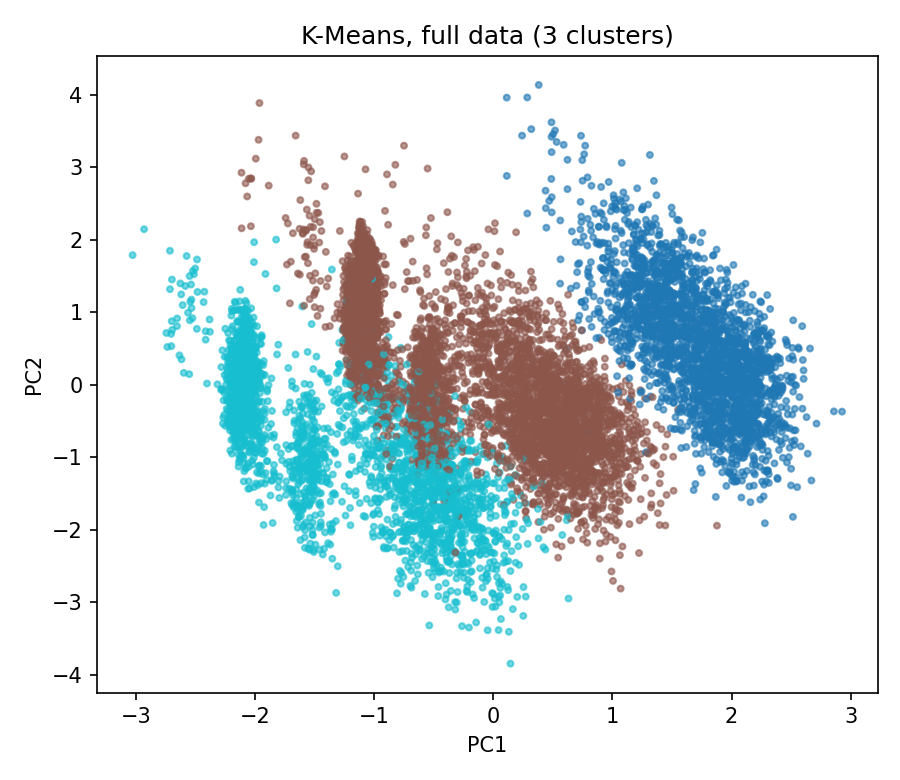

In [6]:
# ---------------------------------------------------------------------------
# 5. PCA for visualization (K-Means portion)
# ---------------------------------------------------------------------------
X_pca_full = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

# K-Means plot (full data)
fig, ax = plt.subplots(figsize=(6, 5.2))
ax.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=km_labels, cmap="tab10", s=8, alpha=0.6)
ax.set_title(f"K-Means, full data ({best_k} clusters)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("kmeans_pca.png", dpi=150)
print("Saved plot -> kmeans_pca.png")
plt.close(fig)

## Week 10

In [7]:
# ---------------------------------------------------------------------------
# 4. Hierarchical + DBSCAN on a subsample (tractable for O(n^2) methods)
# ---------------------------------------------------------------------------
sub_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), 5000, replace=False)
X_sub = X[sub_idx]

hc = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hc_labels = hc.fit_predict(X_sub)
sil_hc = silhouette_score(X_sub, hc_labels)
print(f"\nHierarchical (k={best_k}, subsample n=5000) silhouette: {sil_hc:.3f}")

db = DBSCAN(eps=2.15, min_samples=15)
db_labels = db.fit_predict(X_sub)
n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int(np.sum(db_labels == -1))
print(f"DBSCAN (subsample n=5000): {n_db_clusters} clusters, {n_noise} noise points")
if n_db_clusters >= 2:
    mask = db_labels != -1
    print(f"DBSCAN silhouette (excl. noise): {silhouette_score(X_sub[mask], db_labels[mask]):.3f}")


Hierarchical (k=3, subsample n=5000) silhouette: 0.119
DBSCAN (subsample n=5000): 6 clusters, 214 noise points
DBSCAN silhouette (excl. noise): 0.133


Saved plot -> dendrogram.png


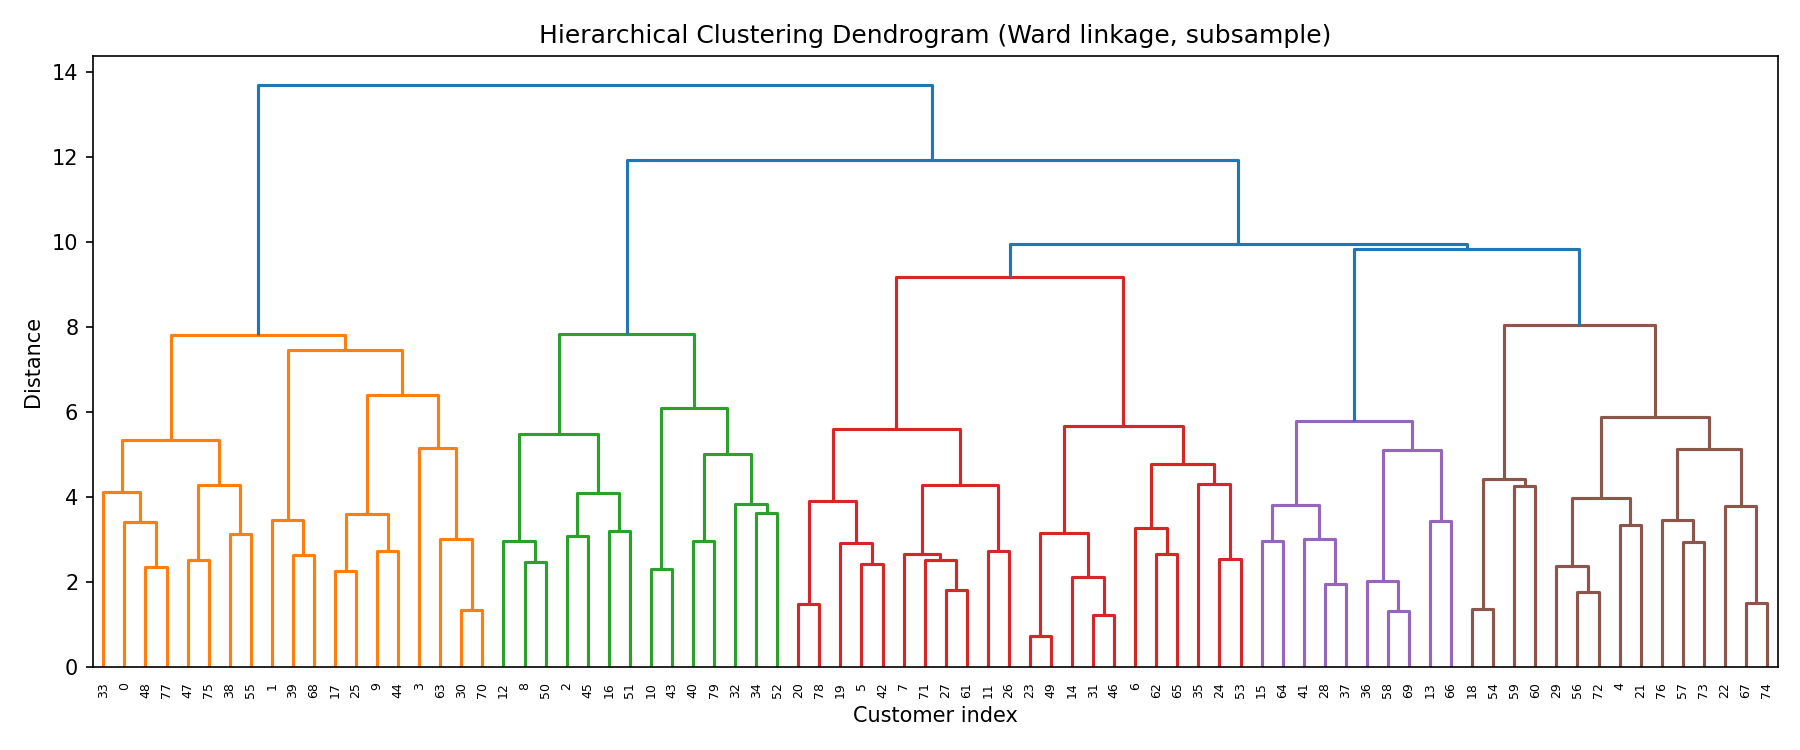

In [8]:
# --- Dendrogram (subsample of the subsample, for readability) ---
dendro_idx = np.random.choice(len(X_sub), size=min(80, len(X_sub)), replace=False)
Z = linkage(X_sub[dendro_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, subsample)")
plt.xlabel("Customer index")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150)
print("Saved plot -> dendrogram.png")
plt.close()

Saved plot -> hierarchical_dbscan_pca.png


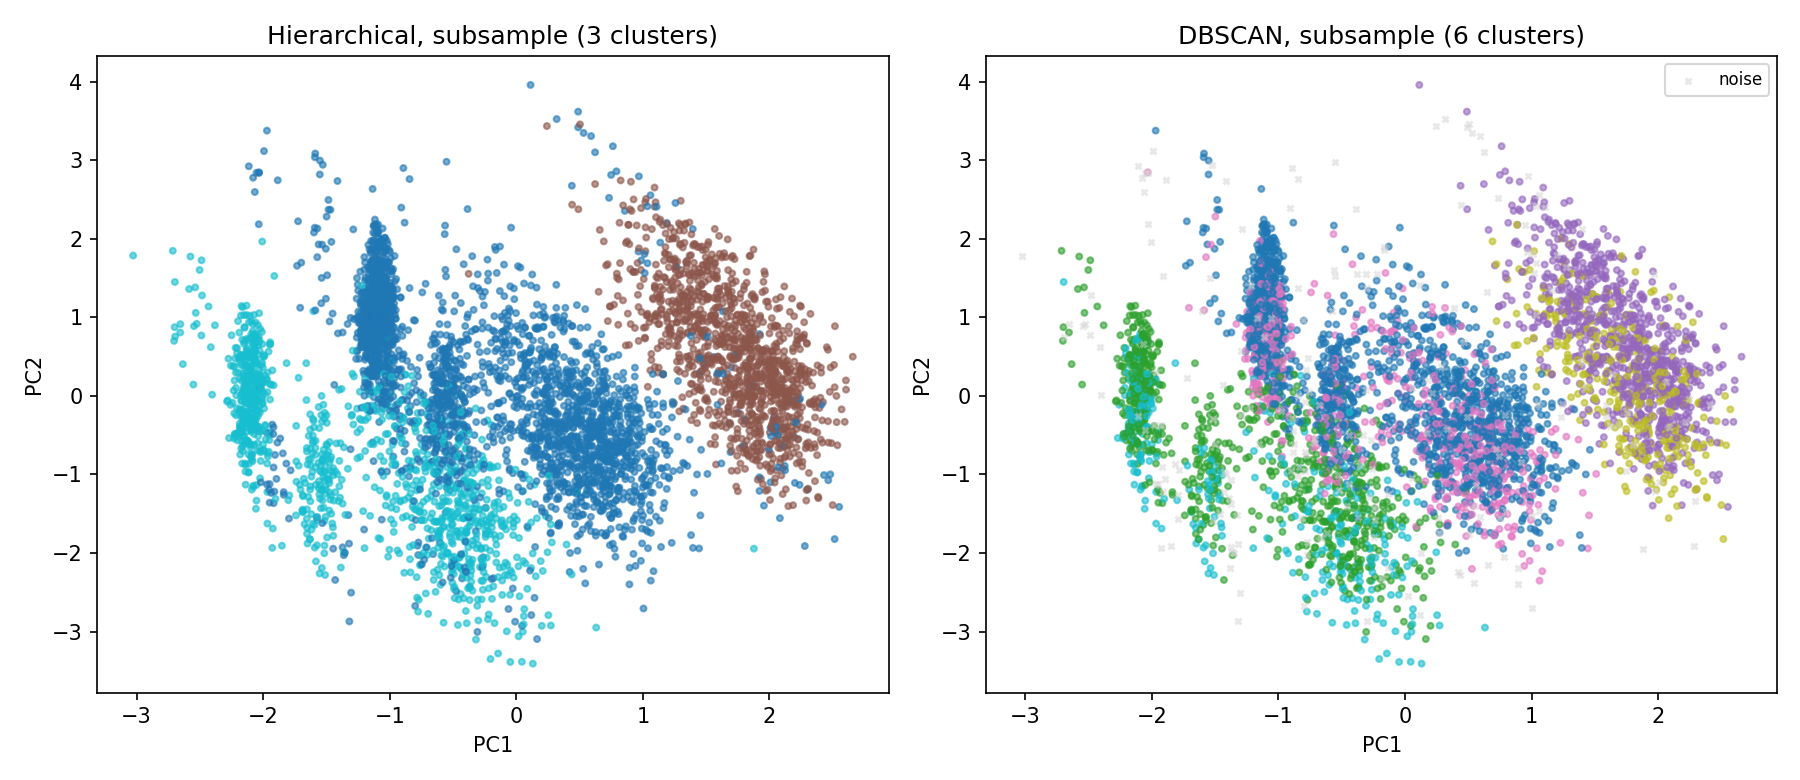

In [9]:
# ---------------------------------------------------------------------------
# 5. PCA for visualization (Hierarchical + DBSCAN portion)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
coords_sub = X_pca_full[sub_idx]

axes[0].scatter(coords_sub[:, 0], coords_sub[:, 1], c=hc_labels, cmap="tab10", s=8, alpha=0.6)
axes[0].set_title(f"Hierarchical, subsample ({best_k} clusters)")

noise_mask = db_labels == -1
axes[1].scatter(
    coords_sub[~noise_mask, 0], coords_sub[~noise_mask, 1],
    c=db_labels[~noise_mask], cmap="tab10", s=8, alpha=0.6,
)
axes[1].scatter(
    coords_sub[noise_mask, 0], coords_sub[noise_mask, 1],
    c="lightgray", s=8, alpha=0.5, marker="x", label="noise",
)
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title(f"DBSCAN, subsample ({n_db_clusters} clusters)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig("hierarchical_dbscan_pca.png", dpi=150)
print("Saved plot -> hierarchical_dbscan_pca.png")
plt.close(fig)

In [10]:
# ---------------------------------------------------------------------------
# 6. Save deliverable: original data + cluster assignment
# ---------------------------------------------------------------------------
df_out = df.copy()
df_out["KMeansCluster"] = km_labels
df_out.to_csv("churn_predict_with_clusters.csv", index=False)
print("\nSaved deliverable -> churn_predict_with_clusters.csv "
      "(original data + KMeansCluster column)")

print("\nDone. K-Means gives a clean, scalable segmentation of all customers "
      "into profiles; the churn rate per cluster (see cluster_profiles.csv) "
      "shows which profiles need the most retention attention.")


Saved deliverable -> churn_predict_with_clusters.csv (original data + KMeansCluster column)

Done. K-Means gives a clean, scalable segmentation of all customers into profiles; the churn rate per cluster (see cluster_profiles.csv) shows which profiles need the most retention attention.
